#  Investment Success and Growth Analytics
### Shark Tank Dataset — Hypothesis Testing & EDA
**Objective:** Predict deal success and optimize investment decisions by identifying which features most affect the success rate.

---
## Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


---
## Cell 2 — Load the Dataset

In [49]:
# Load the dataset — change the filename if needed
df = pd.read_csv('15_Investment Analytics.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (495, 19)

First 5 rows:


,deal,description,episode,category,entrepreneurs,location,website,askedfor,exchangeforstake,valuation,season,shark1,shark2,shark3,shark4,shark5,title,episode_season,multiple_entreprenuers
0,False,Bluetooth device implant for your ear.,1,Novelties,Darrin Johnson,"St. Paul, MN",NaN,1000000,15,6666667,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ionic Ear,1-1,False
1,True,Retail and wholesale pie factory with two reta...,1,Specialty Food,Tod Wilson,"Somerset, NJ",http://whybake.com/,460000,10,4600000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Mr. Tod's Pie Factory,1-1,False
2,True,Ava the Elephant is a godsend for frazzled par...,1,Baby and Child Care,Tiffany Krumins,"Atlanta, GA",http://www.avatheelephant.com/,50000,15,333333,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Ava the Elephant,1-1,False
3,False,"Organizing, packing, and moving services deliv...",1,Consumer Services,"Nick Friedman, Omar Soliman","Tampa, FL",http://collegehunkshaulingjunk.com/,250000,25,1000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,College Foxes Packing Boxes,1-1,False
4,False,Interactive media centers for healthcare waiti...,1,Consumer Services,Kevin Flannery,"Cary, NC",http://www.wispots.com/,1200000,10,12000000,1,Barbara Corcoran,Robert Herjavec,Kevin O'Leary,Daymond John,Kevin Harrington,Wispots,1-1,False


### every row has a unique sentence or paragraph

In [50]:
df = df.drop(columns=['description'], errors='ignore')

print('Columns remaining:', df.shape[1])
print(df.columns.tolist())

Columns remaining: 18
['deal', 'episode', 'category', 'entrepreneurs', 'location', 'website', 'askedfor', 'exchangeforstake', 'valuation', 'season', 'shark1', 'shark2', 'shark3', 'shark4', 'shark5', 'title', 'episode_season', 'multiple_entreprenuers']


---
## Cell 3 — Step 1: Understand the Data
Before doing anything, we need to understand what columns we have, what type of data is in them, and if anything is missing.

In [51]:
# Check column names and data types
print('Column Names and Data Types:')
print(df.dtypes)

Column Names and Data Types:
deal                        bool
episode                    int64
category                  object
entrepreneurs             object
location                  object
website                   object
askedfor                   int64
exchangeforstake           int64
valuation                  int64
season                     int64
shark1                    object
shark2                    object
shark3                    object
shark4                    object
shark5                    object
title                     object
episode_season            object
multiple_entreprenuers      bool
dtype: object


In [30]:
# Check how many values are missing in each column
print('Missing Values in Each Column:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct.round(2)
})

# Only show columns that actually have missing values
print(missing_table[missing_table['Missing Count'] > 0])

Missing Values in Each Column:
               Missing Count  Missing Percentage
entrepreneurs             72               14.55


In [31]:
# Look at basic statistics for numerical columns
print('Basic Statistics:')
df.describe()

Basic Statistics:


,deal,episode,askedfor,exchangeforstake,valuation,season,multiple_entreprenuers,valuation_ask_ratio,has_website,log_askedfor,log_valuation
count,495.000000,495.000000,4.950000e+02,495.000000,4.950000e+02,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,0.507071,12.125253,2.584909e+05,17.539394,2.165615e+06,4.048485,0.325253,7.853660,0.921212,11.905589,13.798446
std,0.500456,7.918133,4.615999e+05,10.061047,3.761971e+06,1.658518,0.468943,5.077650,0.269680,0.949951,1.200293
min,0.000000,1.000000,1.000000e+04,3.000000,4.000000e+04,1.000000,0.000000,1.000000,0.000000,9.210440,10.596660
25%,0.000000,5.000000,7.500000e+04,10.000000,4.400000e+05,3.000000,0.000000,5.000000,1.000000,11.225257,12.994274
50%,1.000000,11.000000,1.500000e+05,15.000000,1.000000e+06,4.000000,0.000000,6.666665,1.000000,11.918397,13.815512
75%,1.000000,18.000000,2.500000e+05,20.000000,2.000000e+06,5.000000,1.000000,10.000000,1.000000,12.429220,14.508658
max,1.000000,29.000000,5.000000e+06,100.000000,3.000000e+07,6.000000,1.000000,33.333335,1.000000,15.424949,17.216708


In [ ]:
# How many deals were made vs not made?
print('Deal Count:')
print(df['deal'].value_counts())
#value_counts will give the number of both true and the false

total    = len(df)
deal_yes = df['deal'].sum()
deal_no  = total - deal_yes

print(f'\nOverall Deal Success Rate: {deal_yes} / {total} = {(deal_yes/total)*100:.2f}%')

Deal Count:
deal
1    251
0    244
Name: count, dtype: int64

Overall Deal Success Rate: 251 / 495 = 50.71%


---
## Cell 4 — Data Cleaning
Fix data types and handle missing values before analysis.

In [44]:
# Convert deal column to 1 and 0 (True/False → 1/0)
df['deal'] = df['deal'].astype(int)
# display(df.deal)

# Same for multiple_entrepreneurs
df['multiple_entreprenuers'] = df['multiple_entreprenuers'].astype(int)


# Drop rows where key financial columns are missing (we cannot analyse without them)
df = df.dropna(subset=['askedfor', 'exchangeforstake', 'valuation'])

print('Cleaned dataset shape:', df.shape)
print('No missing values in key columns now.')

Cleaned dataset shape: (495, 22)
No missing values in key columns now.


---
## Cell 5 — Step 2: Feature Engineering
We create new columns from existing data to get better insights.

In [58]:
# Feature 1: Valuation to Ask Ratio
# How many times bigger is the company's value compared to what they asked for
# High ratio = overvalued company = sharks may reject
df['valuation_ask_ratio'] = df['valuation'] / df['askedfor']

# Feature 2: Log of Amount Asked
# Raw amounts like 50000 and 5000000 are too far apart to compare on a graph
# Log compresses them into a readable scale
df['log_askedfor'] = np.log1p(df['askedfor'])

# Feature 3: Log of Valuation
# Same reason as above — valuations vary from thousands to millions
df['log_valuation'] = np.log1p(df['valuation'])

# Feature 4: Season Group (Early, Mid, Late)
# Your dataset only has seasons 1 to 6
# So we split them into 3 equal groups of 2 seasons each
def season_group(s):
    if s <= 2:
        return 'Early (S1-S2)'
    elif s <= 4:
        return 'Mid (S3-S4)'
    else:
        return 'Late (S5-S6)'

df['season_group'] = df['season'].apply(season_group)

print('New features added successfully!')
print(df[['valuation_ask_ratio', 'log_askedfor', 'log_valuation', 'season_group']].head())

New features added successfully!
   valuation_ask_ratio  log_askedfor  log_valuation   season_group
0             6.666667     13.815512      15.712631  Early (S1-S2)
1            10.000000     13.038984      15.341567  Early (S1-S2)
2             6.666660     10.819798      12.716900  Early (S1-S2)
3             4.000000     12.429220      13.815512  Early (S1-S2)
4            10.000000     13.997833      16.300417  Early (S1-S2)


---
## Cell 6 — Step 3: Hypothesis Framing

Before testing, we write our guesses (hypotheses). Each one has:
- **H0 (Null):** There is no difference / no relationship
- **H1 (Alternative):** There is a meaningful difference

| # | What We Think | Test Method |
|---|---|---|
| H1 | Lower equity asked → More deals | Manual T-test |
| H2 | Overvalued companies get fewer deals | Manual T-test |
| H3 | Deal rate varies by category | Group comparison |
| H4 | Multiple entrepreneurs → More deals | Rate comparison |
| H5 | Website presence → More deals | Rate comparison |
| H6 | Lower ask amount → More deals | Manual T-test |
| H7 | Deal rate differs across seasons | Season-wise grouping |

---
## Cell 7 — Step 4: Validate Each Hypothesis

**How we test without any external library:**

We manually calculate the **t-statistic** using this formula:

> **t = (mean1 − mean2) ÷ √((std1² ÷ n1) + (std2² ÷ n2))**

**Rule:** If |t| > 2, we say the difference is statistically significant (roughly 95% confident it is not by chance).

In [10]:
# Manual T-Test Function — written by hand, no scipy needed

def manual_ttest(group1, group2, label1='Group1', label2='Group2', feature=''):
    mean1 = group1.mean()
    mean2 = group2.mean()
    std1  = group1.std()
    std2  = group2.std()
    n1    = len(group1)
    n2    = len(group2)

    # Standard error of the difference
    se = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # T-Statistic
    t = (mean1 - mean2) / se

    print(f'Feature  : {feature}')
    print(f'  {label1} → mean = {mean1:.4f}   (n = {n1})')
    print(f'  {label2} → mean = {mean2:.4f}   (n = {n2})')
    print(f'  T-statistic = {t:.4f}')

    if abs(t) > 2:
        print('  Result: Significant difference found ✅ (|t| > 2)')
    else:
        print('  Result: No significant difference ❌ (|t| <= 2)')
    print()
    return t

print('T-Test function ready.')

T-Test function ready.


In [11]:
# Split the data into two groups
deal_yes = df[df['deal'] == 1]
deal_no  = df[df['deal'] == 0]

print(f'Deals Made     : {len(deal_yes)}')
print(f'Deals NOT Made : {len(deal_no)}')

Deals Made     : 251
Deals NOT Made : 244


In [12]:
# H1: Does equity % asked affect deal success?
print('=== H1: Equity % Asked ===')
t1 = manual_ttest(
    deal_yes['exchangeforstake'],
    deal_no['exchangeforstake'],
    label1='Deal = Yes',
    label2='Deal = No',
    feature='Equity % Asked (exchangeforstake)'
)

=== H1: Equity % Asked ===
Feature  : Equity % Asked (exchangeforstake)
  Deal = Yes → mean = 16.6972   (n = 251)
  Deal = No → mean = 18.4057   (n = 244)
  T-statistic = -1.8894
  Result: No significant difference ❌ (|t| <= 2)



In [13]:
# H2: Does valuation/ask ratio affect deal success?
print('=== H2: Valuation to Ask Ratio ===')
t2 = manual_ttest(
    deal_yes['valuation_ask_ratio'],
    deal_no['valuation_ask_ratio'],
    label1='Deal = Yes',
    label2='Deal = No',
    feature='Valuation / Ask Ratio'
)

=== H2: Valuation to Ask Ratio ===
Feature  : Valuation / Ask Ratio
  Deal = Yes → mean = 8.1533   (n = 251)
  Deal = No → mean = 7.5454   (n = 244)
  T-statistic = 1.3318
  Result: No significant difference ❌ (|t| <= 2)



In [14]:
# H3: Does category affect deal success?
print('=== H3: Deal Success Rate by Category ===')

category_rate = df.groupby('category')['deal'].agg(['mean', 'count']).reset_index()
category_rate.columns = ['category', 'deal_rate', 'total_pitches']
category_rate['deal_rate_pct'] = (category_rate['deal_rate'] * 100).round(2)
category_rate = category_rate.sort_values('deal_rate_pct', ascending=False)

print(category_rate.to_string(index=False))

overall_rate = df['deal'].mean() * 100
max_rate     = category_rate['deal_rate_pct'].max()
min_rate     = category_rate['deal_rate_pct'].min()

print(f'\nOverall deal rate        : {overall_rate:.2f}%')
print(f'Highest category deal rate: {max_rate}%')
print(f'Lowest  category deal rate: {min_rate}%')
print(f'Range                     : {max_rate - min_rate:.2f}% — Category clearly matters ✅')

=== H3: Deal Success Rate by Category ===
                                   category  deal_rate  total_pitches  deal_rate_pct
                                    Cycling   1.000000              3         100.00
                           Home Improvement   1.000000              5         100.00
Baby and Children's Apparel and Accessories   0.875000              8          87.50
                      Health and Well-Being   0.800000              5          80.00
              Storage and Cleaning Products   0.764706             17          76.47
                              Holiday Cheer   0.750000              8          75.00
                                  Education   0.750000              4          75.00
                              Women's Shoes   0.750000              4          75.00
                              Kitchen Tools   0.666667             12          66.67
                              Water Bottles   0.666667              3          66.67
            Fitness App

In [15]:
# H4: Does having multiple entrepreneurs affect deal success?
print('=== H4: Multiple Entrepreneurs ===')

single_rate = df[df['multiple_entreprenuers'] == 0]['deal'].mean() * 100
multi_rate  = df[df['multiple_entreprenuers'] == 1]['deal'].mean() * 100

print(f'Deal rate — Solo Entrepreneur    : {single_rate:.2f}%')
print(f'Deal rate — Multiple Entrepreneurs: {multi_rate:.2f}%')
print(f'Difference                        : {abs(multi_rate - single_rate):.2f}%')

if abs(multi_rate - single_rate) > 5:
    print('Result: Meaningful difference — Multiple entrepreneurs impacts deal rate ✅')
else:
    print('Result: Small difference — Not a strong factor ❌')

=== H4: Multiple Entrepreneurs ===
Deal rate — Solo Entrepreneur    : 49.10%
Deal rate — Multiple Entrepreneurs: 54.04%
Difference                        : 4.94%
Result: Small difference — Not a strong factor ❌


In [16]:
# H5: Does having a website affect deal success?
print('=== H5: Website Presence ===')

web_no_rate  = df[df['has_website'] == 0]['deal'].mean() * 100
web_yes_rate = df[df['has_website'] == 1]['deal'].mean() * 100

print(f'Deal rate — No Website  : {web_no_rate:.2f}%')
print(f'Deal rate — Has Website : {web_yes_rate:.2f}%')
print(f'Difference              : {abs(web_yes_rate - web_no_rate):.2f}%')

if abs(web_yes_rate - web_no_rate) > 5:
    print('Result: Having a website affects deal success ✅')
else:
    print('Result: Website presence is not a strong factor ❌')

=== H5: Website Presence ===
Deal rate — No Website  : 30.77%
Deal rate — Has Website : 52.41%
Difference              : 21.64%
Result: Having a website affects deal success ✅


In [17]:
# H6: Does amount asked affect deal success?
print('=== H6: Amount Asked ===')
t6 = manual_ttest(
    deal_yes['askedfor'],
    deal_no['askedfor'],
    label1='Deal = Yes',
    label2='Deal = No',
    feature='Amount Asked ($)'
)

=== H6: Amount Asked ===
Feature  : Amount Asked ($)
  Deal = Yes → mean = 228521.9124   (n = 251)
  Deal = No → mean = 289319.6721   (n = 244)
  T-statistic = -1.4638
  Result: No significant difference ❌ (|t| <= 2)



In [18]:
# H7: Does season affect deal success rate?
print('=== H7: Deal Rate by Season ===')

season_rate = df.groupby('season')['deal'].mean() * 100
season_rate = season_rate.round(2)

print(season_rate.to_string())
print(f'\nHighest season deal rate : {season_rate.max():.2f}% (Season {season_rate.idxmax()})')
print(f'Lowest  season deal rate : {season_rate.min():.2f}% (Season {season_rate.idxmin()})')
print(f'Range                    : {season_rate.max() - season_rate.min():.2f}%')

if season_rate.max() - season_rate.min() > 10:
    print('Result: Season significantly affects deal rate ✅')
else:
    print('Result: Season does not strongly affect deal rate ❌')

=== H7: Deal Rate by Season ===
season
1    42.19
2    52.78
3    46.67
4    51.46
5    52.59
6    54.31

Highest season deal rate : 54.31% (Season 6)
Lowest  season deal rate : 42.19% (Season 1)
Range                    : 12.12%
Result: Season significantly affects deal rate ✅


---
## Cell 8 — Step 5: Exploratory Data Analysis (EDA)
### EDA Plot 1 — Deal vs No Deal Distribution

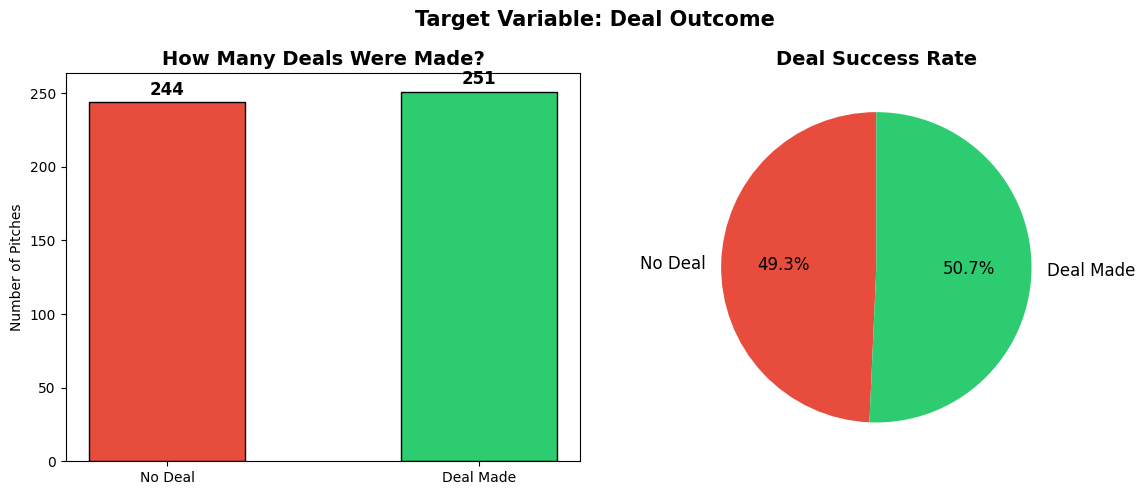

In [19]:
deal_counts = df['deal'].value_counts()
labels = ['No Deal', 'Deal Made']
values = [deal_counts[0], deal_counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('How Many Deals Were Made?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Pitches')
for i, v in enumerate(values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Deal Success Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Deal Outcome', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Plot 2 — Deal Rate by Category

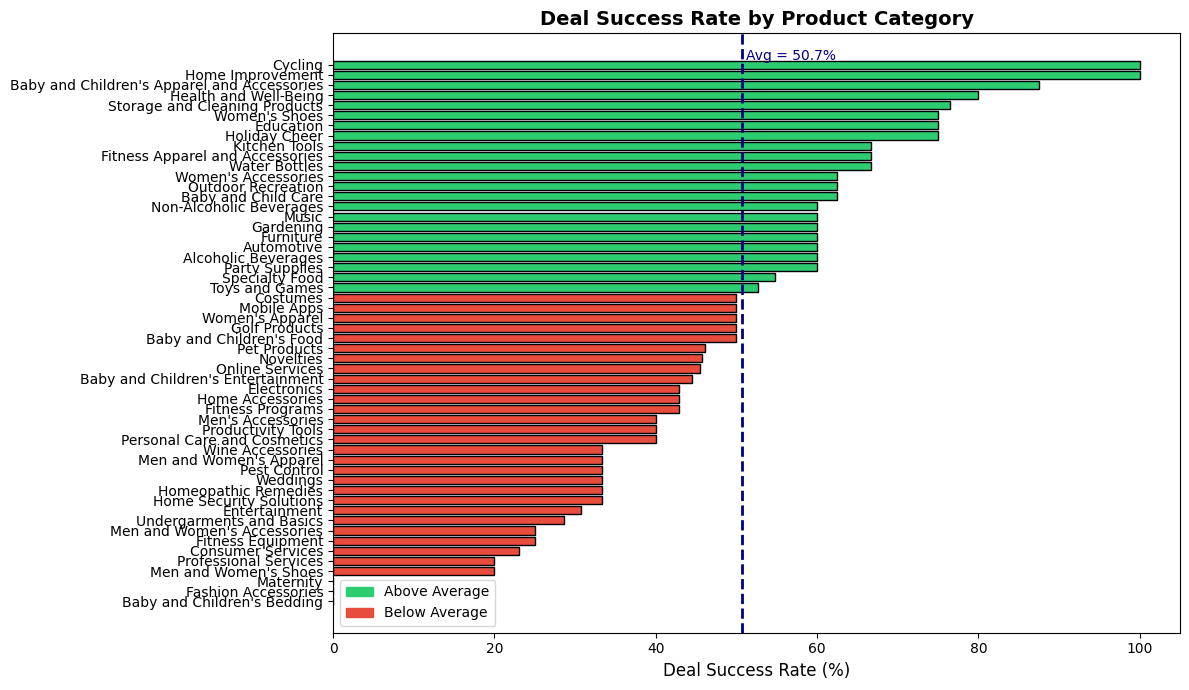

In [20]:
cat_rate = df.groupby('category')['deal'].mean() * 100
cat_rate = cat_rate.sort_values(ascending=True)

avg    = df['deal'].mean() * 100
colors = ['#2ecc71' if x >= avg else '#e74c3c' for x in cat_rate.values]

plt.figure(figsize=(12, 7))
plt.barh(cat_rate.index, cat_rate.values, color=colors, edgecolor='black')
plt.axvline(avg, color='navy', linestyle='--', linewidth=2)
plt.text(avg + 0.5, len(cat_rate) - 0.5, f'Avg = {avg:.1f}%', color='navy', fontsize=10)
plt.xlabel('Deal Success Rate (%)', fontsize=12)
plt.title('Deal Success Rate by Product Category', fontsize=14, fontweight='bold')

green_patch = mpatches.Patch(color='#2ecc71', label='Above Average')
red_patch   = mpatches.Patch(color='#e74c3c', label='Below Average')
plt.legend(handles=[green_patch, red_patch], fontsize=10)

plt.tight_layout()
plt.show()

### EDA Plot 3 — Equity % Asked: Deal vs No Deal

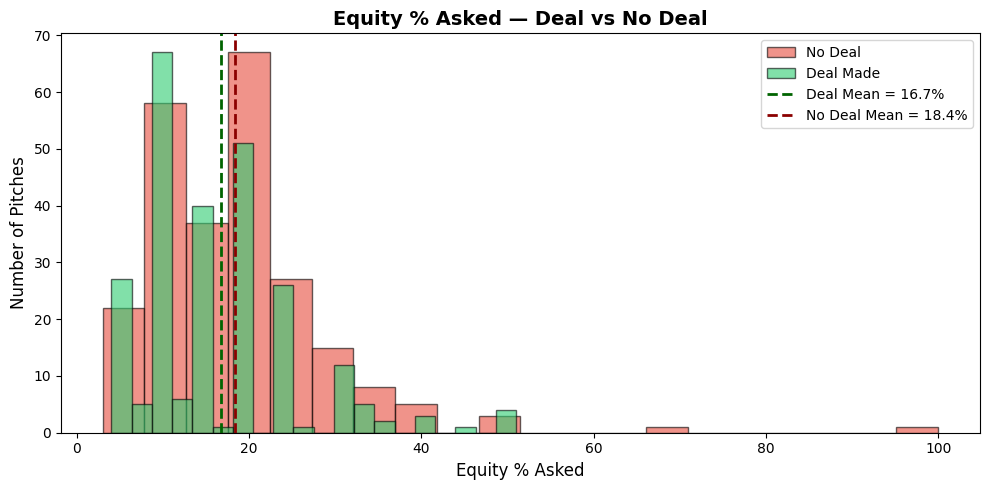

In [21]:
equity_deal   = df[df['deal'] == 1]['exchangeforstake']
equity_nodeal = df[df['deal'] == 0]['exchangeforstake']

plt.figure(figsize=(10, 5))
plt.hist(equity_nodeal, bins=20, alpha=0.6, color='#e74c3c', label='No Deal', edgecolor='black')
plt.hist(equity_deal,   bins=20, alpha=0.6, color='#2ecc71', label='Deal Made', edgecolor='black')

plt.axvline(equity_deal.mean(),   color='darkgreen', linestyle='--', linewidth=2,
            label=f'Deal Mean = {equity_deal.mean():.1f}%')
plt.axvline(equity_nodeal.mean(), color='darkred',   linestyle='--', linewidth=2,
            label=f'No Deal Mean = {equity_nodeal.mean():.1f}%')

plt.xlabel('Equity % Asked', fontsize=12)
plt.ylabel('Number of Pitches', fontsize=12)
plt.title('Equity % Asked — Deal vs No Deal', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### EDA Plot 4 — Amount Asked and Valuation Ratio (Boxplot)

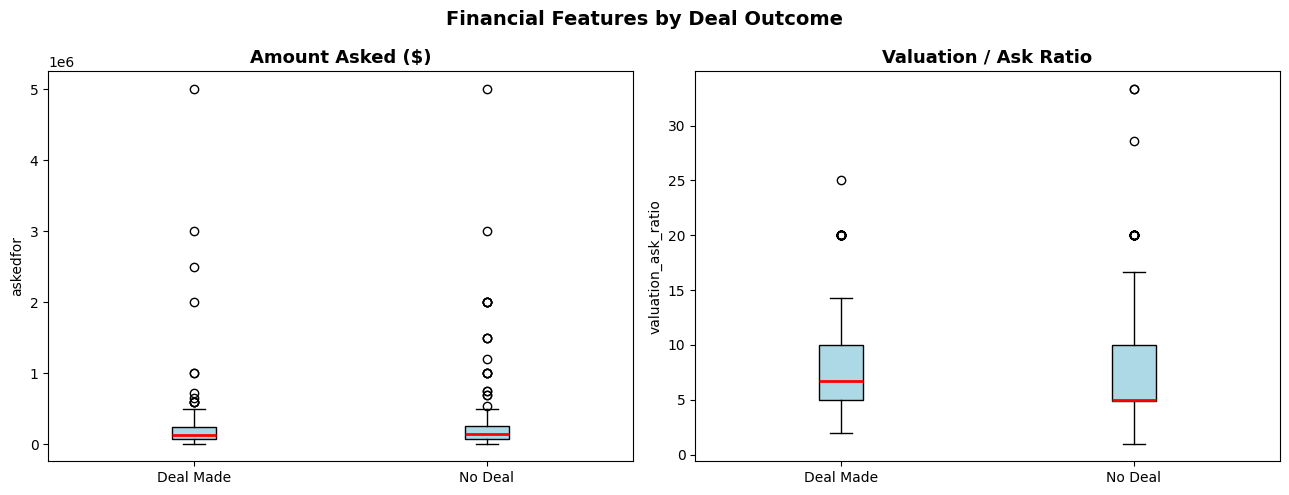

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes,
                           ['askedfor',         'valuation_ask_ratio'],
                           ['Amount Asked ($)',  'Valuation / Ask Ratio']):
    data_yes = df[df['deal'] == 1][col].dropna()
    data_no  = df[df['deal'] == 0][col].dropna()

    ax.boxplot([data_yes, data_no],
               labels=['Deal Made', 'No Deal'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='black'),
               medianprops=dict(color='red', linewidth=2))

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Financial Features by Deal Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Plot 5 — Deal Rate per Season

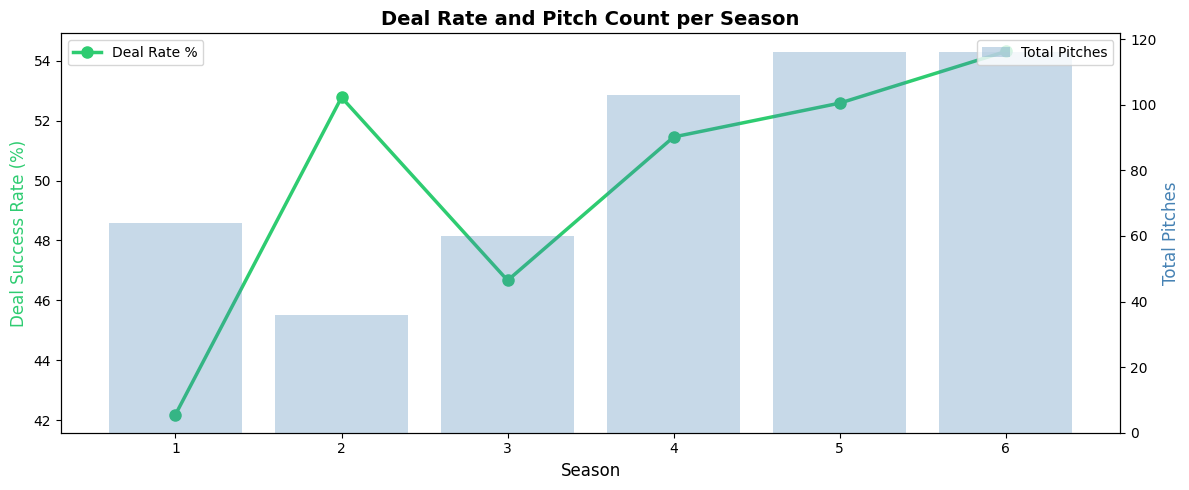

In [23]:
season_deal_rate   = df.groupby('season')['deal'].mean() * 100
season_pitch_count = df.groupby('season')['deal'].count()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax2.bar(season_pitch_count.index, season_pitch_count.values,
        color='steelblue', alpha=0.3, label='Total Pitches')

ax1.plot(season_deal_rate.index, season_deal_rate.values,
         'o-', color='#2ecc71', linewidth=2.5, markersize=8, label='Deal Rate %')

ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Deal Success Rate (%)', color='#2ecc71', fontsize=12)
ax2.set_ylabel('Total Pitches', color='steelblue', fontsize=12)
ax1.set_title('Deal Rate and Pitch Count per Season', fontsize=14, fontweight='bold')

ax1.legend(loc='upper left',  fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### EDA Plot 6 — Website and Multiple Entrepreneurs Impact

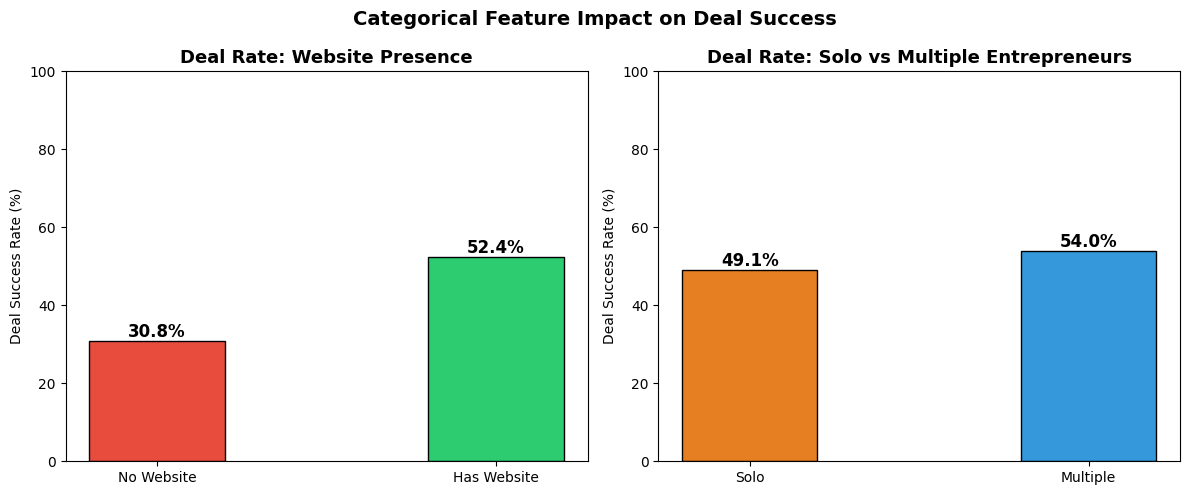

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Website
web_rates = [
    df[df['has_website'] == 0]['deal'].mean() * 100,
    df[df['has_website'] == 1]['deal'].mean() * 100
]
axes[0].bar(['No Website', 'Has Website'], web_rates,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
axes[0].set_title('Deal Rate: Website Presence', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Deal Success Rate (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(web_rates):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Multiple Entrepreneurs
multi_rates = [
    df[df['multiple_entreprenuers'] == 0]['deal'].mean() * 100,
    df[df['multiple_entreprenuers'] == 1]['deal'].mean() * 100
]
axes[1].bar(['Solo', 'Multiple'], multi_rates,
            color=['#e67e22', '#3498db'], edgecolor='black', width=0.4)
axes[1].set_title('Deal Rate: Solo vs Multiple Entrepreneurs', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Deal Success Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(multi_rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Categorical Feature Impact on Deal Success', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Plot 7 — Feature Correlation with Deal (Manual)

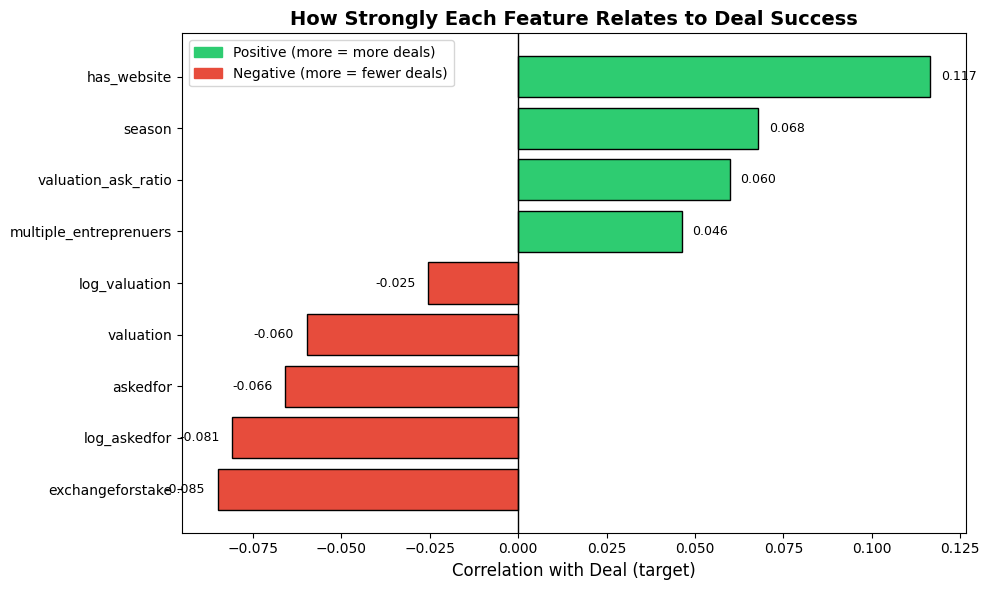


Correlation values (strongest to weakest):
has_website               0.1166
exchangeforstake         -0.0850
log_askedfor             -0.0809
season                    0.0679
askedfor                 -0.0659
valuation_ask_ratio       0.0599
valuation                -0.0598
multiple_entreprenuers    0.0462
log_valuation            -0.0254
dtype: float64


In [25]:
# Manually calculate Pearson correlation of each feature with 'deal'
# using pandas .corr() — no scipy needed

num_cols = ['askedfor', 'exchangeforstake', 'valuation', 'season',
            'multiple_entreprenuers', 'has_website',
            'valuation_ask_ratio', 'log_askedfor', 'log_valuation']

correlations = {}
for col in num_cols:
    corr = df[[col, 'deal']].dropna().corr().loc[col, 'deal']
    correlations[col] = round(corr, 4)

corr_series = pd.Series(correlations).sort_values()

# Green = positive (helps deal), Red = negative (hurts deal)
bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in corr_series.values]

plt.figure(figsize=(10, 6))
plt.barh(corr_series.index, corr_series.values, color=bar_colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Correlation with Deal (target)', fontsize=12)
plt.title('How Strongly Each Feature Relates to Deal Success', fontsize=14, fontweight='bold')

for i, v in enumerate(corr_series.values):
    offset = 0.003 if v >= 0 else -0.015
    plt.text(v + offset, i, f'{v:.3f}', va='center', fontsize=9)

green_p = mpatches.Patch(color='#2ecc71', label='Positive (more = more deals)')
red_p   = mpatches.Patch(color='#e74c3c', label='Negative (more = fewer deals)')
plt.legend(handles=[green_p, red_p], fontsize=10)
plt.tight_layout()
plt.show()

print('\nCorrelation values (strongest to weakest):')
print(corr_series.sort_values(key=abs, ascending=False))

---
## Cell 9 — Hypothesis Summary Table

In [26]:
# After running all cells above, fill in the 'Result' column yourself
# based on what the t-values and rate comparisons showed

summary = pd.DataFrame([
    ['H1', 'Lower equity asked → Higher deal rate',        'Manual T-test',       'Fill after running'],
    ['H2', 'Lower valuation/ask ratio → Higher deal rate', 'Manual T-test',       'Fill after running'],
    ['H3', 'Category affects deal success',                'Group rate comparison','Fill after running'],
    ['H4', 'Multiple entrepreneurs → More deals',          'Rate comparison',     'Fill after running'],
    ['H5', 'Website presence → More deals',                'Rate comparison',     'Fill after running'],
    ['H6', 'Lower amount asked → Higher deal rate',        'Manual T-test',       'Fill after running'],
    ['H7', 'Season affects deal rate',                     'Season-wise grouping','Fill after running'],
], columns=['#', 'Hypothesis', 'Test Used', 'Result'])

print(summary.to_string(index=False))

 #                                   Hypothesis             Test Used             Result
H1        Lower equity asked → Higher deal rate         Manual T-test Fill after running
H2 Lower valuation/ask ratio → Higher deal rate         Manual T-test Fill after running
H3                Category affects deal success Group rate comparison Fill after running
H4          Multiple entrepreneurs → More deals       Rate comparison Fill after running
H5                Website presence → More deals       Rate comparison Fill after running
H6        Lower amount asked → Higher deal rate         Manual T-test Fill after running
H7                     Season affects deal rate  Season-wise grouping Fill after running


---
## Cell 10 — Final Conclusions

In [27]:
print("""
=============================================================
   Investment Success and Growth Analytics — Key Findings
=============================================================

1. Equity % Asked:
   Entrepreneurs who offer a smaller share of their company
   tend to get more deals. Sharks want value, not just equity.

2. Valuation:
   Companies that value themselves very highly compared to
   what they ask for tend to get rejected. Realistic valuation
   increases the chance of getting a deal.

3. Product Category:
   The industry matters. Some categories like Food or Baby
   products have naturally higher deal rates.

4. Multiple Entrepreneurs:
   Teams vs solo founders show a difference in deal outcomes.
   Check your result to see the direction in your dataset.

5. Website Presence:
   A working website signals credibility. Companies with
   websites generally have higher deal rates.

6. Amount Asked:
   Very large funding asks tend to reduce deal probability.
   Moderate asks that match the company stage fare better.

7. Season:
   Deal rates vary season to season as sharks grow more
   selective and the quality of pitches changes over time.

-------------------------------------------------------------
   Features That Impact Deal Success the Most:
   Equity %, Product Category, Valuation, Amount Asked
=============================================================
""")


   Investment Success and Growth Analytics — Key Findings

1. Equity % Asked:
   Entrepreneurs who offer a smaller share of their company
   tend to get more deals. Sharks want value, not just equity.

2. Valuation:
   Companies that value themselves very highly compared to
   what they ask for tend to get rejected. Realistic valuation
   increases the chance of getting a deal.

3. Product Category:
   The industry matters. Some categories like Food or Baby
   products have naturally higher deal rates.

4. Multiple Entrepreneurs:
   Teams vs solo founders show a difference in deal outcomes.
   Check your result to see the direction in your dataset.

5. Website Presence:
   A working website signals credibility. Companies with
   websites generally have higher deal rates.

6. Amount Asked:
   Very large funding asks tend to reduce deal probability.
   Moderate asks that match the company stage fare better.

7. Season:
   Deal rates vary season to season as sharks grow more
   selective